# Model Results Visualisation

This notebook consolidates the aligned `1day`, `5days`, and `20days` forecasting outputs for:
- Logistic regression
- XGBoost
- PatchTST
- LSTM

It reads the exported artifacts under `reports/` and writes refreshed static figures to
`reports/figures/model_results_visualisation/`.


In [24]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.bbox"] = "tight"


def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists() or (candidate / "README.md").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root from notebook location")


ROOT = find_repo_root(Path.cwd())
REPORTS_DIR = ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures" / "model_results_visualisation"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

HORIZONS = ["1day", "5days", "20days"]
MODEL_ORDER = ["Logistic", "XGBoost", "PatchTST", "LSTM"]
MODEL_COLORS = {
    "Logistic": "#355C7D",
    "XGBoost": "#C06C84",
    "PatchTST": "#F67280",
    "LSTM": "#6C5B7B",
}


def save_current_figure(name: str) -> Path:
    path = FIGURES_DIR / name
    plt.savefig(path)
    return path


In [25]:
PREDICTION_SPECS = {
    "Logistic": {
        "1day": REPORTS_DIR / "trained_logistic" / "basecase_1day" / "predictions.csv",
        "5days": REPORTS_DIR / "trained_logistic" / "basecase_5days" / "predictions.csv",
        "20days": REPORTS_DIR / "trained_logistic" / "basecase_20days" / "predictions.csv",
    },
    "XGBoost": {
        "1day": REPORTS_DIR / "trained_xgboost" / "basecase_1day" / "predictions.csv",
        "5days": REPORTS_DIR / "trained_xgboost" / "basecase_5days" / "predictions.csv",
        "20days": REPORTS_DIR / "trained_xgboost" / "basecase_20days" / "predictions.csv",
    },
    "PatchTST": {
        "1day": REPORTS_DIR / "trained_patchtst" / "results_lag_1" / "predictions.csv",
        "5days": REPORTS_DIR / "trained_patchtst" / "results_lag_5" / "predictions.csv",
        "20days": REPORTS_DIR / "trained_patchtst" / "results_lag_20" / "predictions.csv",
    },
    "LSTM": {
        "1day": REPORTS_DIR / "trained_ltsm" / "results_lag_1" / "predictions.csv",
        "5days": REPORTS_DIR / "trained_ltsm" / "results_lag_5" / "predictions.csv",
        "20days": REPORTS_DIR / "trained_ltsm" / "results_lag_20" / "predictions.csv",
    },
}

SPLIT_LABELS = {
    "Logistic": "validation",
    "XGBoost": "validation",
    "PatchTST": "test",
    "LSTM": "test",
}


def normalise_prediction_frame(df: pd.DataFrame, model: str, horizon: str) -> pd.DataFrame:
    frame = df.copy()

    rename_map = {}
    if "date" in frame.columns:
        rename_map["date"] = "Date"
    if "y_prob" in frame.columns:
        rename_map["y_prob"] = "y_pred_prob"
    frame = frame.rename(columns=rename_map)

    required = ["Date", "y_true", "y_pred", "y_pred_prob"]
    missing = [col for col in required if col not in frame.columns]
    if missing:
        raise KeyError(f"{model} {horizon} missing columns: {missing}")

    frame["Date"] = pd.to_datetime(frame["Date"])
    frame["model"] = model
    frame["horizon"] = horizon
    frame["split"] = SPLIT_LABELS[model]
    return frame[["Date", "y_true", "y_pred", "y_pred_prob", "model", "split", "horizon"]]


def load_all_predictions() -> pd.DataFrame:
    frames = []
    for model, horizon_map in PREDICTION_SPECS.items():
        for horizon, path in horizon_map.items():
            df = pd.read_csv(path)
            frames.append(normalise_prediction_frame(df, model=model, horizon=horizon))

    combined = pd.concat(frames, ignore_index=True)
    combined["horizon"] = pd.Categorical(combined["horizon"], categories=HORIZONS, ordered=True)
    combined["model"] = pd.Categorical(combined["model"], categories=MODEL_ORDER, ordered=True)
    return combined.sort_values(["horizon", "model", "Date"]).reset_index(drop=True)


def summarise_metrics(predictions: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (model, horizon, split), df in predictions.groupby(["model", "horizon", "split"], observed=True):
        rows.append(
            {
                "model": model,
                "horizon": horizon,
                "split": split,
                "accuracy": accuracy_score(df["y_true"], df["y_pred"]),
                "precision": precision_score(df["y_true"], df["y_pred"], zero_division=0),
                "recall": recall_score(df["y_true"], df["y_pred"], zero_division=0),
                "f1_score": f1_score(df["y_true"], df["y_pred"], zero_division=0),
                "roc_auc": roc_auc_score(df["y_true"], df["y_pred_prob"]),
                "rows": len(df),
                "start_date": df["Date"].min(),
                "end_date": df["Date"].max(),
            }
        )
    metrics = pd.DataFrame(rows)
    metrics["horizon"] = pd.Categorical(metrics["horizon"], categories=HORIZONS, ordered=True)
    metrics["model"] = pd.Categorical(metrics["model"], categories=MODEL_ORDER, ordered=True)
    return metrics.sort_values(["horizon", "model"]).reset_index(drop=True)


def load_cross_validation_artifacts():
    logistic_test = pd.read_csv(REPORTS_DIR / "trained_logistic" / "cross_validation" / "test_metrics.csv")
    logistic_test["model"] = "Logistic"
    logistic_test["horizon"] = "1day"

    logistic_cv = pd.read_csv(REPORTS_DIR / "trained_logistic" / "cross_validation" / "cv_summary.csv")
    logistic_cv["model"] = "Logistic"
    logistic_cv["horizon"] = "1day"

    xgb_test = pd.read_csv(REPORTS_DIR / "trained_xgboost" / "cross_validation_1day" / "test_metrics.csv")
    xgb_test["model"] = "XGBoost"
    xgb_test["horizon"] = "1day"

    xgb_grid = pd.read_csv(REPORTS_DIR / "trained_xgboost" / "cross_validation_1day" / "cv_summary.csv")
    xgb_grid["model"] = "XGBoost"
    xgb_grid["horizon"] = "1day"

    return logistic_test, logistic_cv, xgb_test, xgb_grid


def load_training_curves():
    xgb_frames = []
    for horizon in HORIZONS:
        df = pd.read_csv(REPORTS_DIR / "trained_xgboost" / f"basecase_{horizon}" / "learning_curve.csv")
        df["model"] = "XGBoost"
        df["horizon"] = horizon
        xgb_frames.append(df)

    patch_frames = []
    lag_map = {"1day": "results_lag_1", "5days": "results_lag_5", "20days": "results_lag_20"}
    for horizon, folder in lag_map.items():
        df = pd.read_csv(REPORTS_DIR / "trained_patchtst" / folder / "training_history.csv")
        df["model"] = "PatchTST"
        df["horizon"] = horizon
        patch_frames.append(df)

    return pd.concat(xgb_frames, ignore_index=True), pd.concat(patch_frames, ignore_index=True)


def draw_confusion_artifact(ax, title: str, csv_path: Path | None = None, image_path: Path | None = None):
    if csv_path is not None and csv_path.exists():
        df = pd.read_csv(csv_path, index_col=0)
        sns.heatmap(df, annot=True, fmt="g", cmap="Blues", cbar=False, ax=ax)
        ax.set_title(title)
        ax.set_xlabel("")
        ax.set_ylabel("")
        return

    if image_path is not None and image_path.exists():
        img = mpimg.imread(image_path)
        ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")
        return

    ax.text(0.5, 0.5, "Missing artifact", ha="center", va="center")
    ax.set_title(title)
    ax.axis("off")


predictions = load_all_predictions()
metrics = summarise_metrics(predictions)
logistic_cv_test, logistic_cv_folds, xgb_cv_test, xgb_cv_grid = load_cross_validation_artifacts()
xgb_learning_curves, patchtst_training = load_training_curves()

display(metrics)


,model,horizon,split,accuracy,precision,recall,f1_score,roc_auc,rows,start_date,end_date
0,Logistic,1day,validation,0.775476,0.929730,0.758545,0.835458,0.848045,1207,2016-07-08,2021-04-23
1,XGBoost,1day,validation,0.879867,0.950355,0.886439,0.917285,0.948964,1207,2016-07-08,2021-04-23
2,PatchTST,1day,test,0.722411,0.932318,0.657518,0.771169,0.855724,1178,2021-06-07,2026-02-12
3,LSTM,1day,test,0.628788,0.978824,0.490566,0.653574,0.890847,1188,2021-05-21,2026-02-12
4,Logistic,5days,validation,0.694030,0.935170,0.636865,0.757715,0.818131,1206,2016-07-05,2021-04-19
5,XGBoost,5days,validation,0.831675,0.942138,0.826711,0.880658,0.909698,1206,2016-07-05,2021-04-19
6,PatchTST,5days,test,0.736063,0.902711,0.700495,0.788850,0.840605,1148,2021-07-14,2026-02-06
7,LSTM,5days,test,0.536195,0.980583,0.357311,0.523768,0.838950,1188,2021-05-17,2026-02-06
8,Logistic,20days,validation,0.248339,0.000000,0.000000,0.000000,0.603897,1204,2016-06-17,2021-03-30
9,XGBoost,20days,validation,0.397841,0.797342,0.265487,0.398340,0.644008,1204,2016-06-17,2021-03-30


## Unified Forecast Metrics

These metrics are recomputed directly from the exported `predictions.csv` files so that all four model
families are summarised in one consistent table.


In [26]:
summary_cols = ["model", "split", "horizon", "accuracy", "precision", "recall", "f1_score", "roc_auc", "rows", "start_date", "end_date"]
display(metrics[summary_cols].style.format({col: "{:.3f}" for col in ["accuracy", "precision", "recall", "f1_score", "roc_auc"]}))


,model,split,horizon,accuracy,precision,recall,f1_score,roc_auc,rows,start_date,end_date
0,Logistic,validation,1day,0.775,0.930,0.759,0.835,0.848,1207,2016-07-08 00:00:00,2021-04-23 00:00:00
1,XGBoost,validation,1day,0.880,0.950,0.886,0.917,0.949,1207,2016-07-08 00:00:00,2021-04-23 00:00:00
2,PatchTST,test,1day,0.722,0.932,0.658,0.771,0.856,1178,2021-06-07 00:00:00,2026-02-12 00:00:00
3,LSTM,test,1day,0.629,0.979,0.491,0.654,0.891,1188,2021-05-21 00:00:00,2026-02-12 00:00:00
4,Logistic,validation,5days,0.694,0.935,0.637,0.758,0.818,1206,2016-07-05 00:00:00,2021-04-19 00:00:00
5,XGBoost,validation,5days,0.832,0.942,0.827,0.881,0.910,1206,2016-07-05 00:00:00,2021-04-19 00:00:00
6,PatchTST,test,5days,0.736,0.903,0.700,0.789,0.841,1148,2021-07-14 00:00:00,2026-02-06 00:00:00
7,LSTM,test,5days,0.536,0.981,0.357,0.524,0.839,1188,2021-05-17 00:00:00,2026-02-06 00:00:00
8,Logistic,validation,20days,0.248,0.000,0.000,0.000,0.604,1204,2016-06-17 00:00:00,2021-03-30 00:00:00
9,XGBoost,validation,20days,0.398,0.797,0.265,0.398,0.644,1204,2016-06-17 00:00:00,2021-03-30 00:00:00


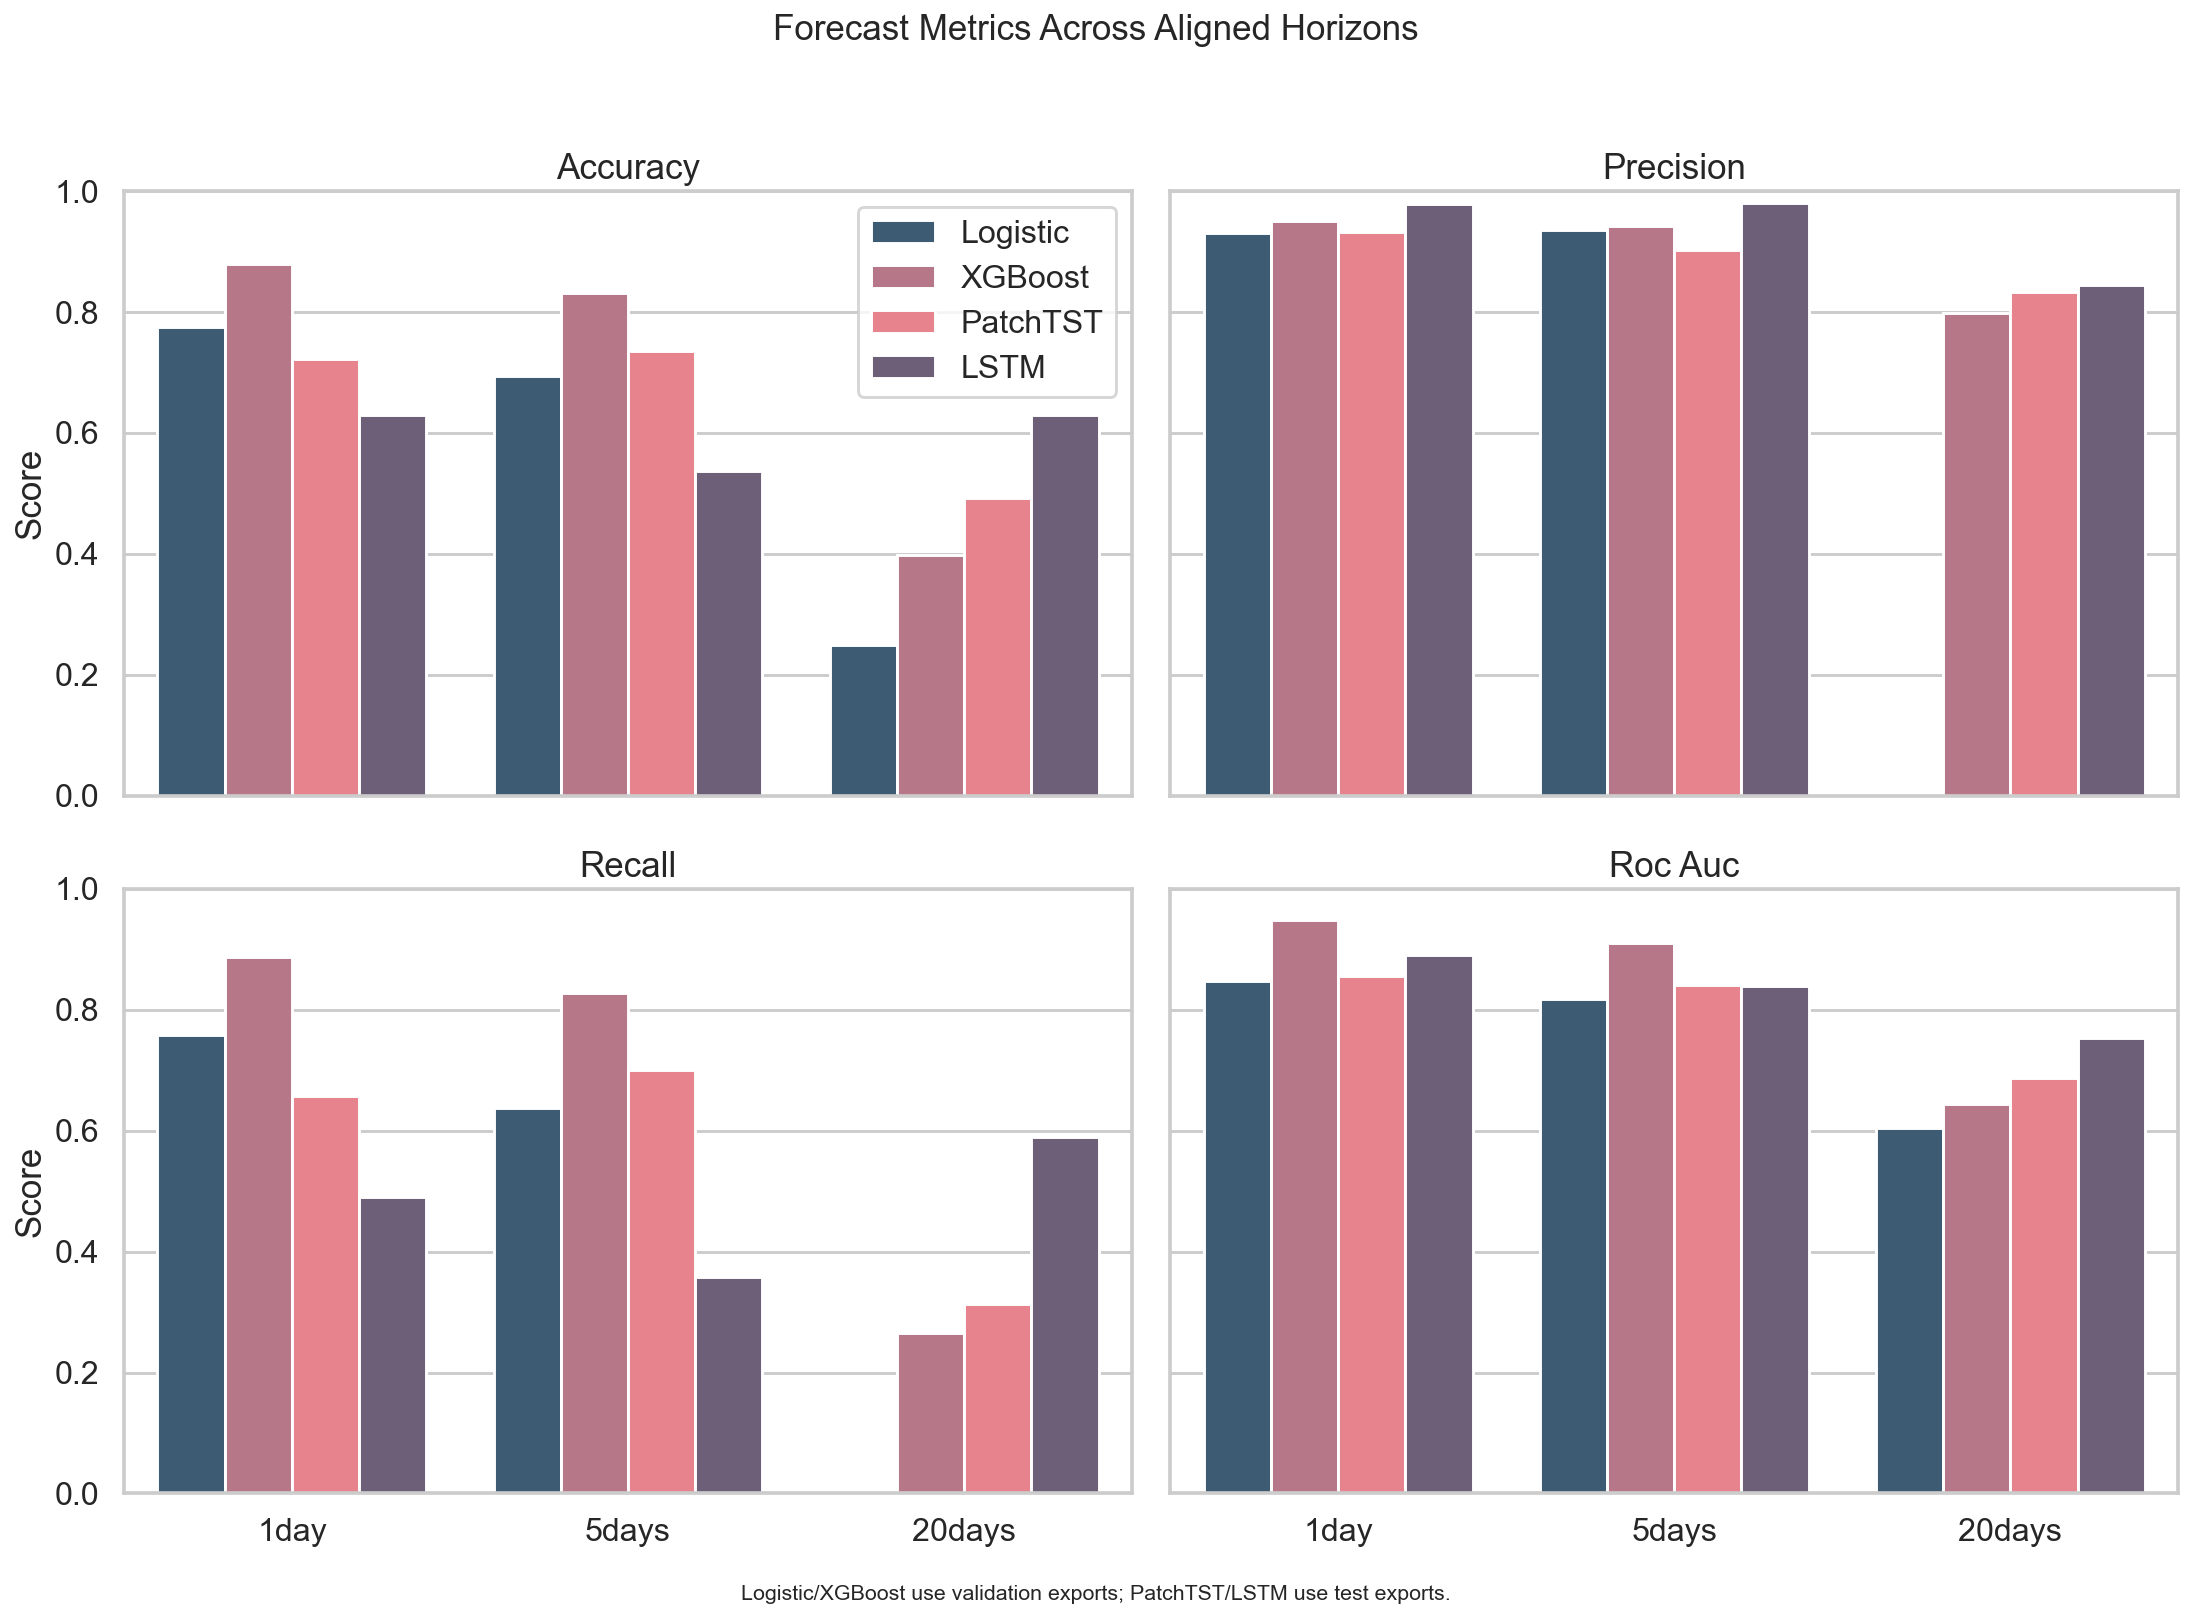

In [27]:
plot_df = metrics.melt(
    id_vars=["model", "horizon", "split"],
    value_vars=["accuracy", "precision", "recall", "roc_auc"],
    var_name="metric",
    value_name="value",
)

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True, sharey=True)
for ax, metric_name in zip(axes.flat, ["accuracy", "precision", "recall", "roc_auc"]):
    subset = plot_df[plot_df["metric"] == metric_name]
    sns.barplot(
        data=subset,
        x="horizon",
        y="value",
        hue="model",
        hue_order=MODEL_ORDER,
        palette=MODEL_COLORS,
        ax=ax,
    )
    ax.set_title(metric_name.replace("_", " ").title())
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.0)
    if ax is axes.flat[0]:
        ax.legend(title="")
    else:
        ax.get_legend().remove()

fig.suptitle("Forecast Metrics Across Aligned Horizons", y=1.02, fontsize=18)
fig.text(0.5, -0.01, "Logistic/XGBoost use validation exports; PatchTST/LSTM use test exports.", ha="center", fontsize=11)
plt.tight_layout()
save_current_figure("aligned_forecast_metrics.png")
plt.show()


## Horizon-Wise Probability Timelines

To make the outputs easier to compare, the plots below use the same format for all four model families.
Each panel shows the last 180 rows of the exported prediction period for one horizon.


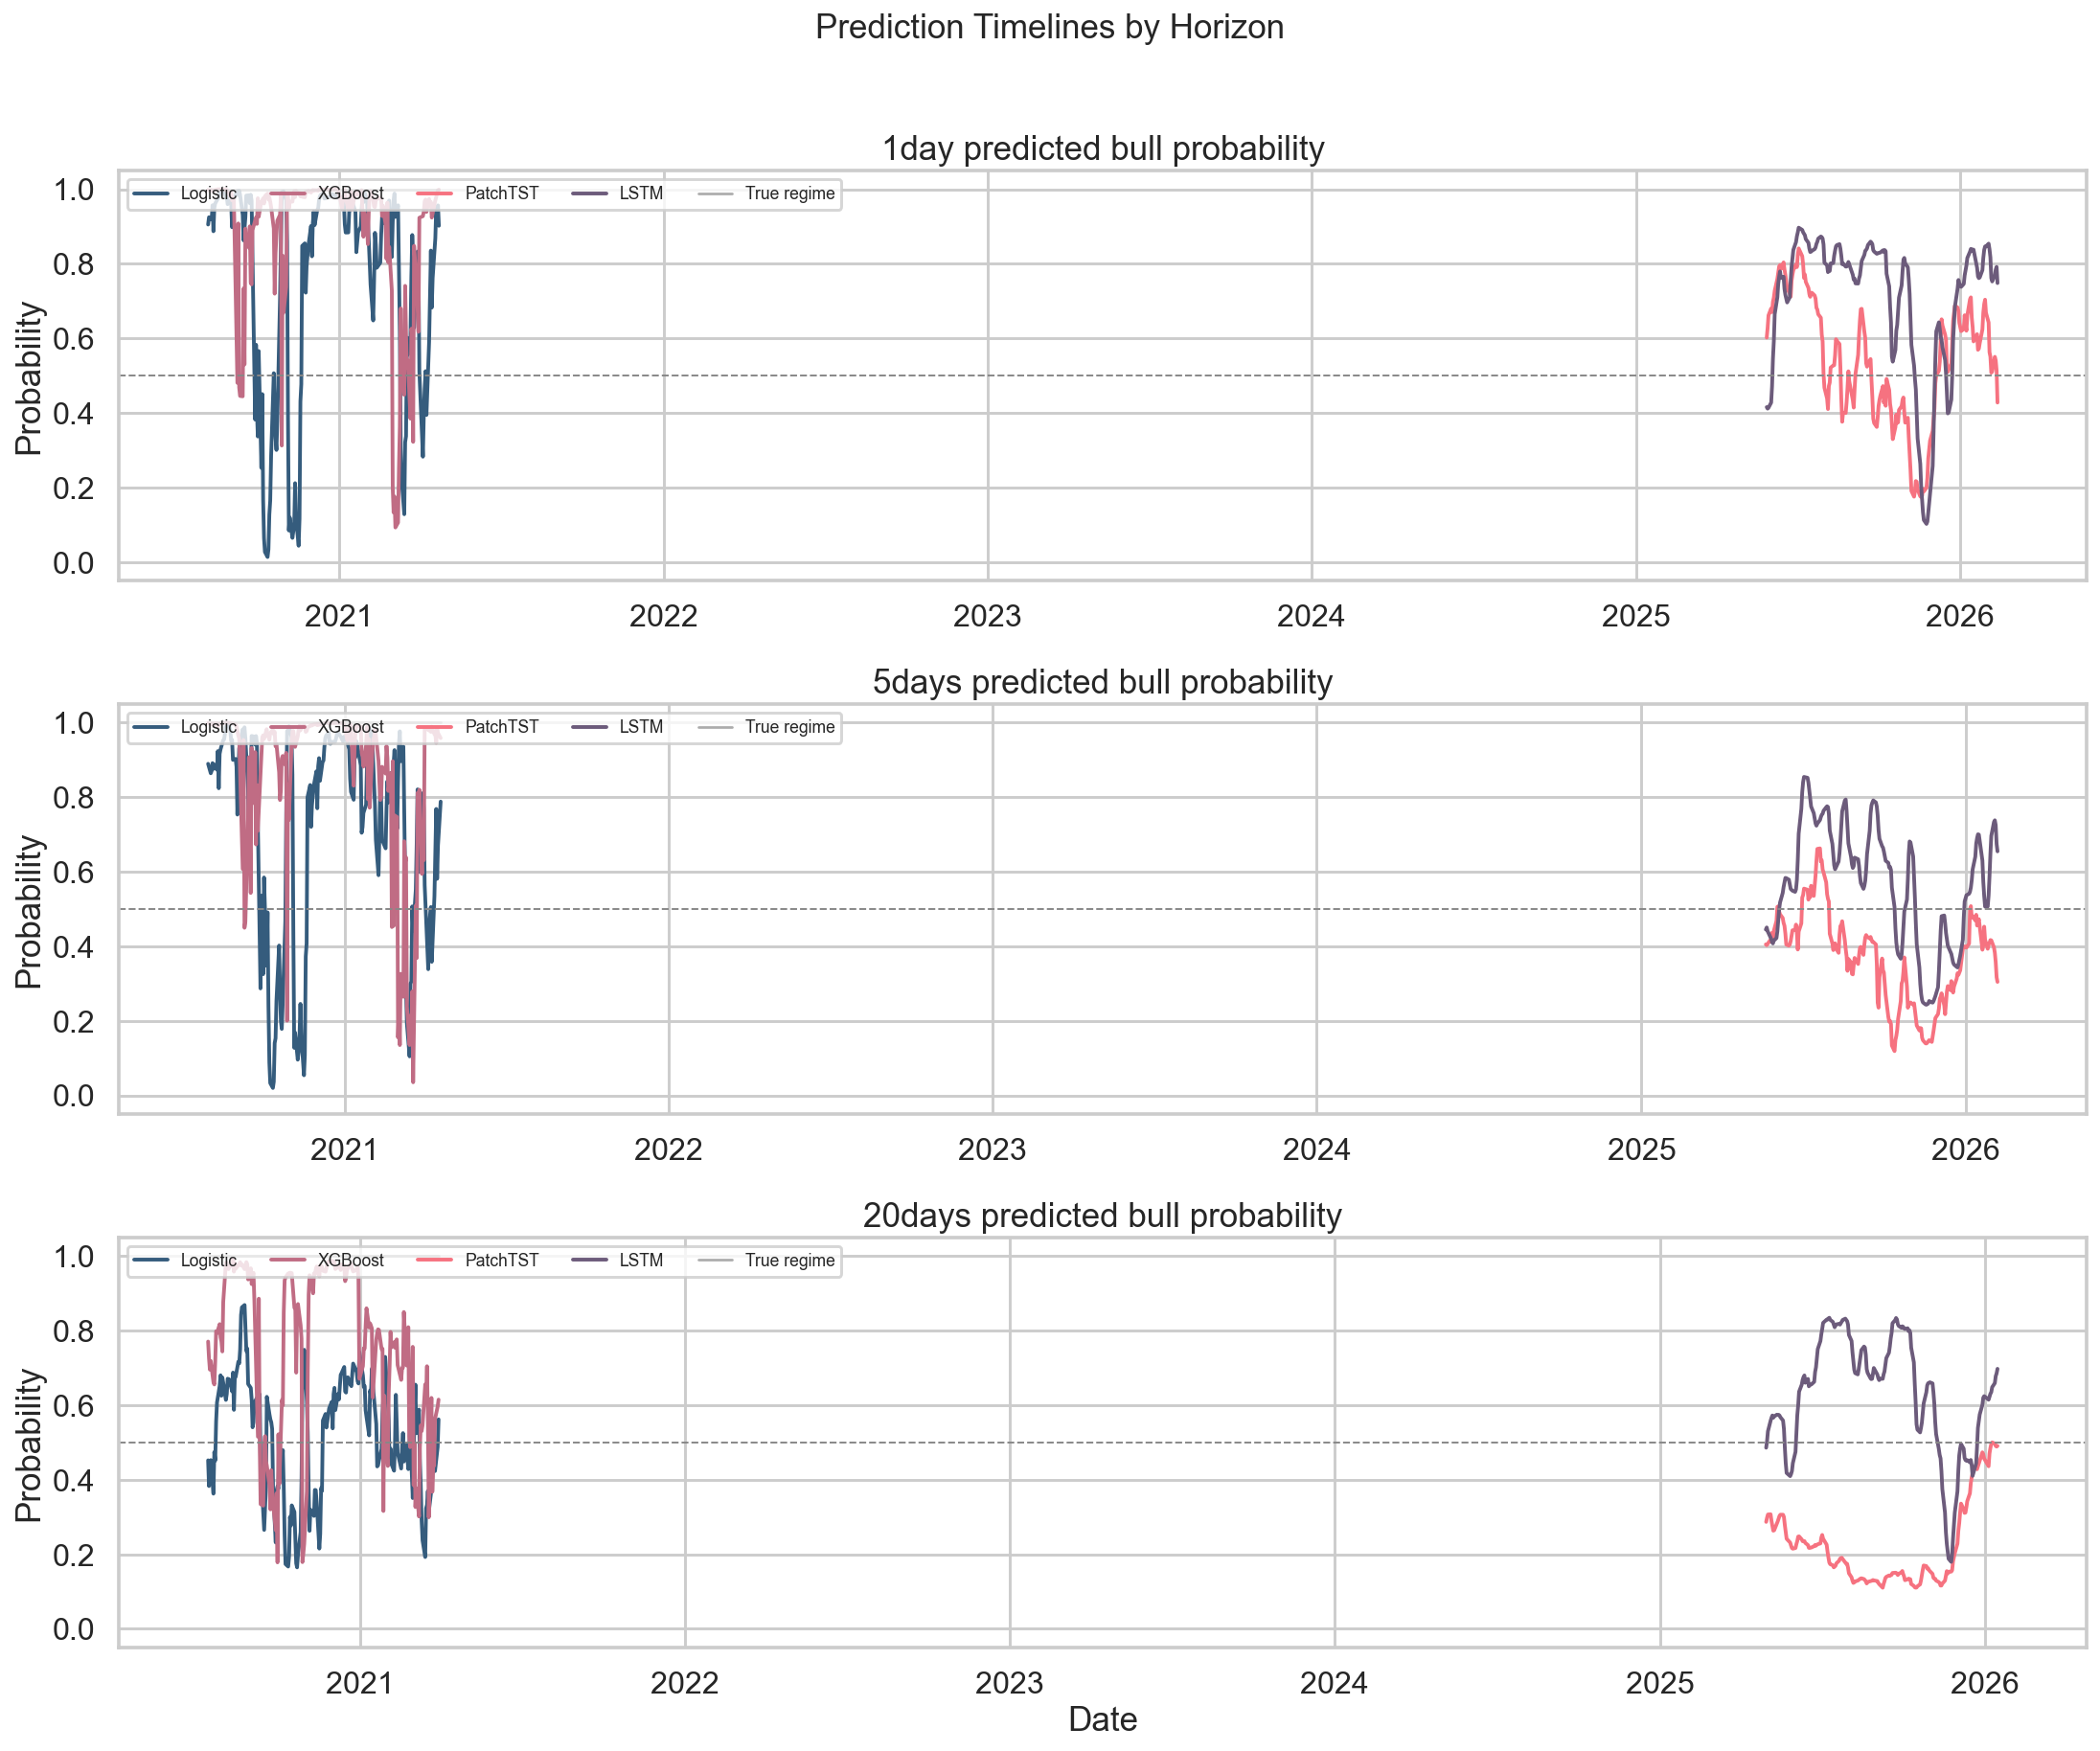

In [28]:
fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(16, 13), sharex=False)
if len(HORIZONS) == 1:
    axes = [axes]

for ax, horizon in zip(axes, HORIZONS):
    subset = predictions[predictions["horizon"] == horizon].copy()
    for model in MODEL_ORDER:
        df = subset[subset["model"] == model].sort_values("Date").tail(180)
        ax.plot(df["Date"], df["y_pred_prob"], label=model, color=MODEL_COLORS[model], linewidth=2)

    truth = subset[subset["model"] == "Logistic"].sort_values("Date").tail(180)
    ax.plot(truth["Date"], truth["y_true"], color="#111111", alpha=0.35, linewidth=1.4, label="True regime")
    ax.axhline(0.5, color="#888888", linestyle="--", linewidth=1)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"{horizon} predicted bull probability")
    ax.set_ylabel("Probability")
    ax.legend(ncol=5, fontsize=9, loc="upper left")

axes[-1].set_xlabel("Date")
fig.suptitle("Prediction Timelines by Horizon", y=1.01, fontsize=18)
plt.tight_layout()
save_current_figure("prediction_timelines_by_horizon.png")
plt.show()


## Model Ranking by Horizon

This view focuses on the strongest headline metric for classification quality.


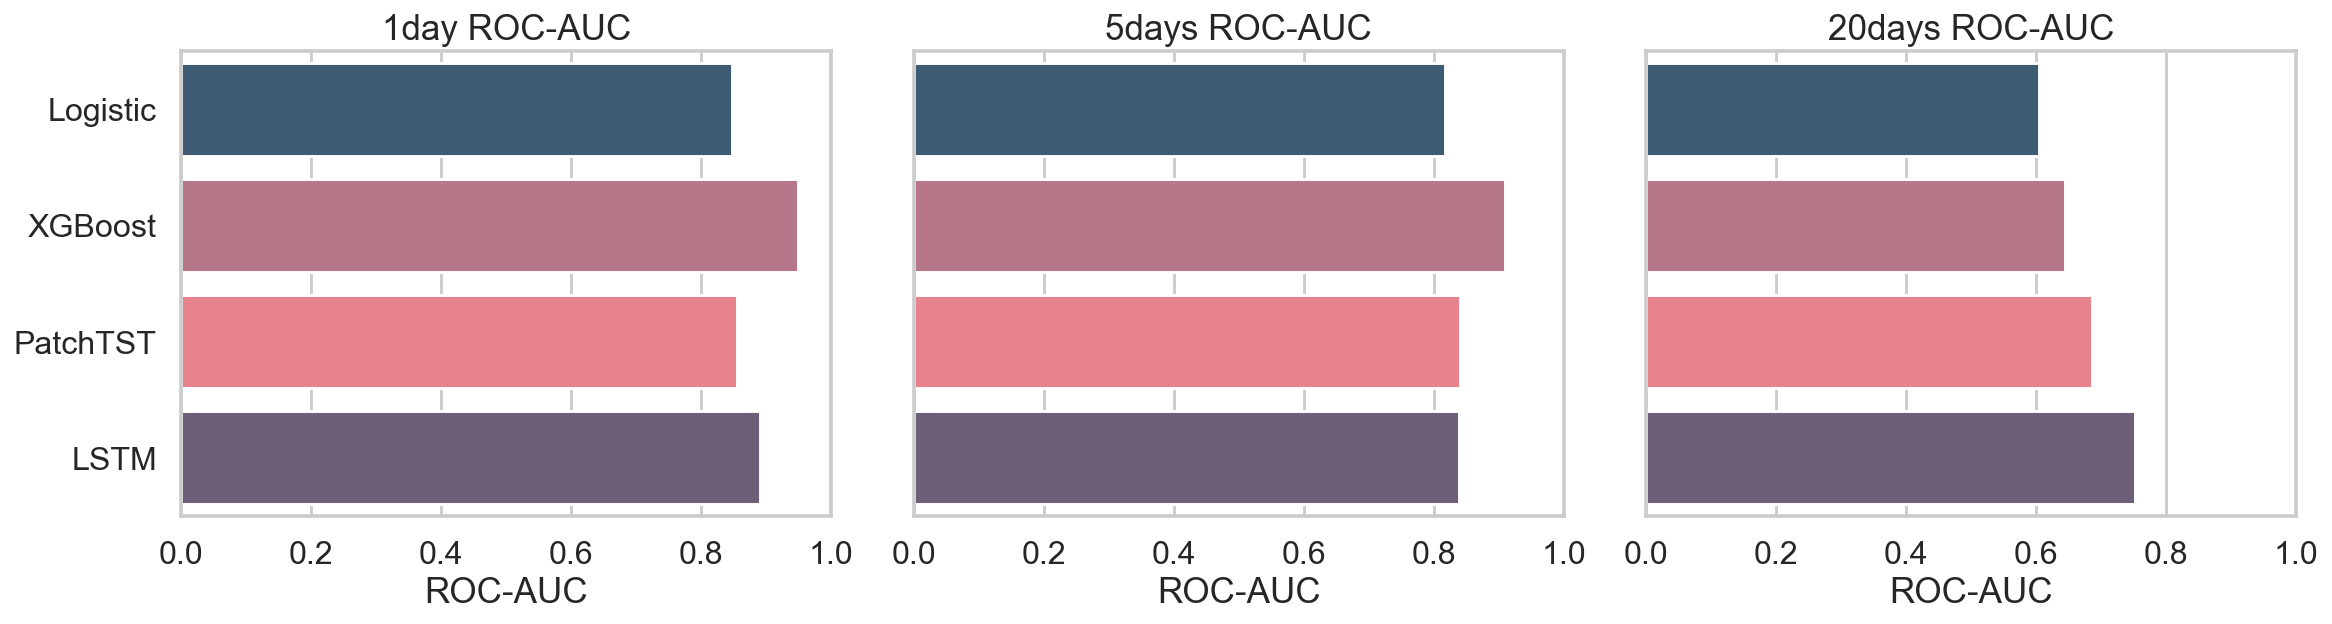

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for ax, horizon in zip(axes, HORIZONS):
    subset = metrics[metrics["horizon"] == horizon].sort_values("roc_auc", ascending=True)
    sns.barplot(
        data=subset,
        x="roc_auc",
        y="model",
        hue="model",
        hue_order=MODEL_ORDER,
        palette=MODEL_COLORS,
        legend=False,
        ax=ax,
    )
    ax.set_title(f"{horizon} ROC-AUC")
    ax.set_xlabel("ROC-AUC")
    ax.set_ylabel("")
    ax.set_xlim(0, 1.0)

plt.tight_layout()
save_current_figure("roc_auc_ranking_by_horizon.png")
plt.show()


## 1-Day Feature Signal Views

The linear and tree baselines still benefit from a direct feature-level readout.


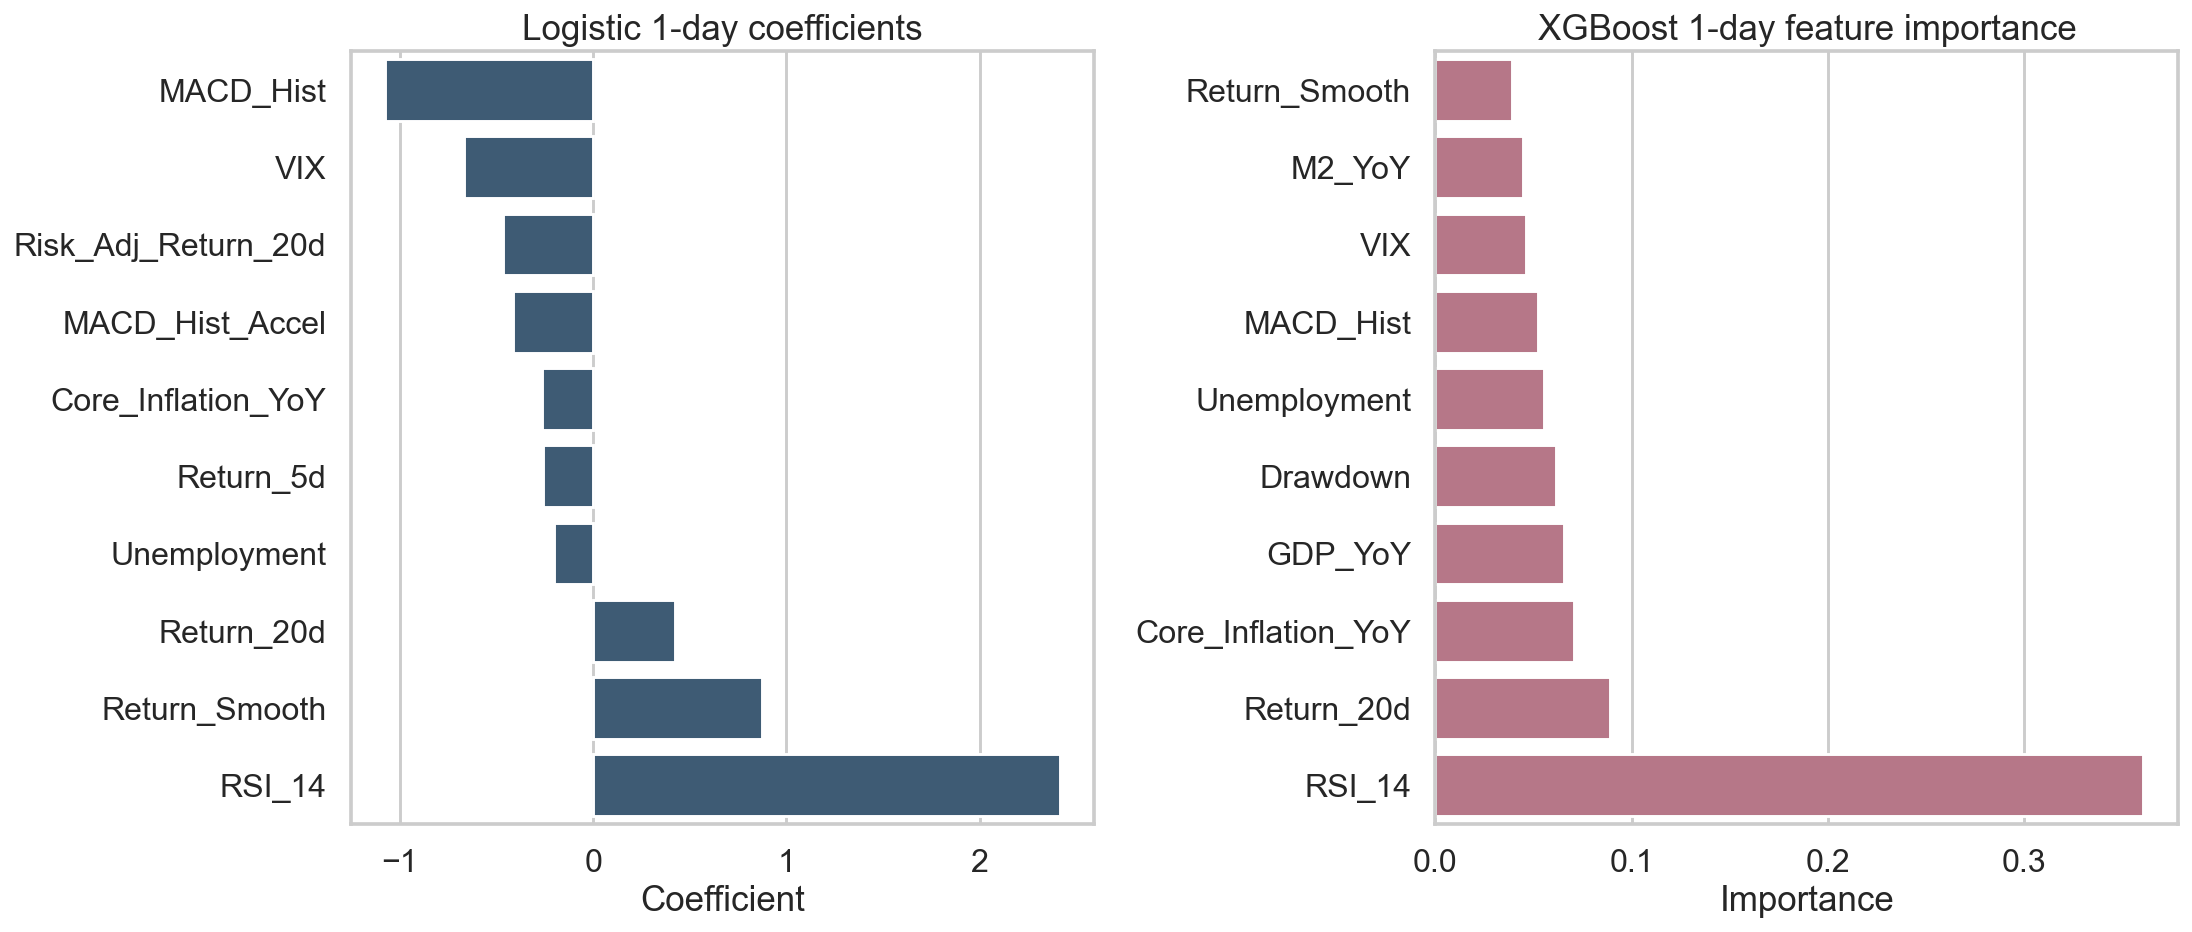

In [30]:
logistic_coef = pd.read_csv(REPORTS_DIR / "trained_logistic" / "basecase_1day" / "coefficients.csv")
logistic_coef = logistic_coef[logistic_coef["feature"] != "const"].copy()
logistic_coef["abs_coefficient"] = logistic_coef["coefficient"].abs()
logistic_top = logistic_coef.nlargest(10, "abs_coefficient").sort_values("coefficient")

xgb_importance = pd.read_csv(REPORTS_DIR / "trained_xgboost" / "basecase_1day" / "feature_importance.csv")
xgb_top = xgb_importance.nlargest(10, "importance").sort_values("importance")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(data=logistic_top, x="coefficient", y="feature", color=MODEL_COLORS["Logistic"], ax=axes[0])
axes[0].set_title("Logistic 1-day coefficients")
axes[0].set_xlabel("Coefficient")
axes[0].set_ylabel("")

sns.barplot(data=xgb_top, x="importance", y="feature", color=MODEL_COLORS["XGBoost"], ax=axes[1])
axes[1].set_title("XGBoost 1-day feature importance")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("")

plt.tight_layout()
save_current_figure("model_signal_views_1day.png")
plt.show()


## Training Diagnostics

Only XGBoost and PatchTST currently export training-curve style artifacts in a structured CSV format.


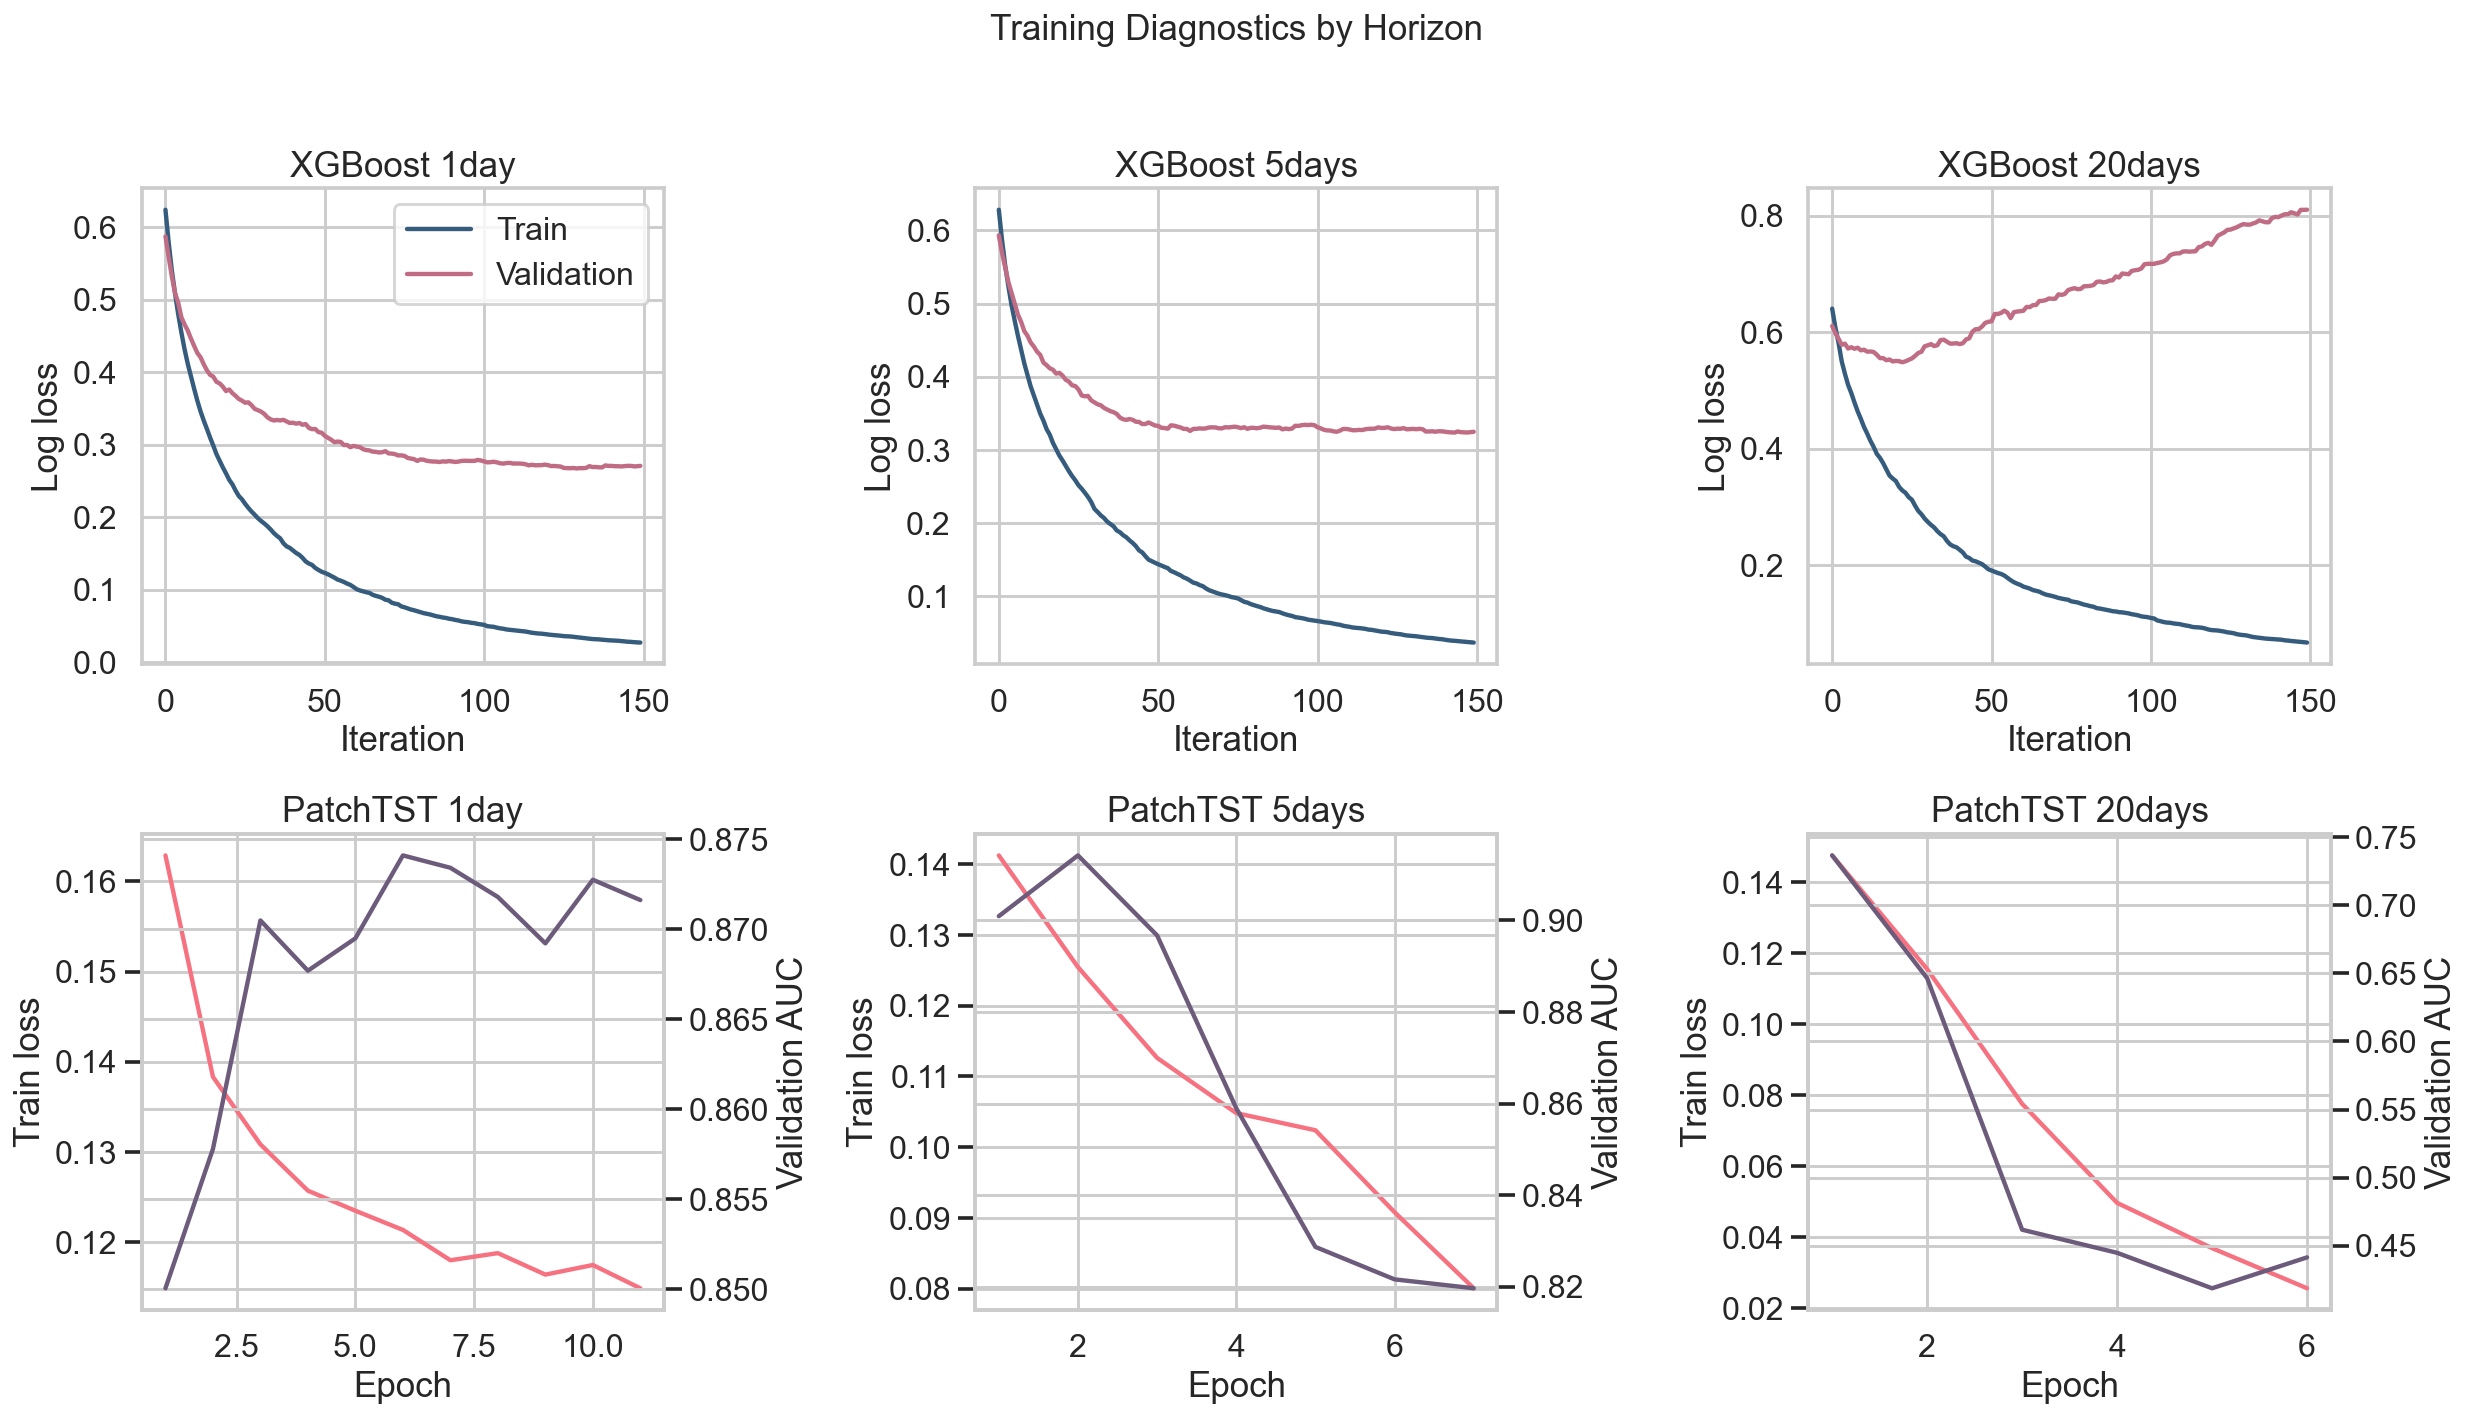

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, horizon in enumerate(HORIZONS):
    xgb_df = xgb_learning_curves[xgb_learning_curves["horizon"] == horizon]
    patch_df = patchtst_training[patchtst_training["horizon"] == horizon]

    ax = axes[0, idx]
    ax.plot(xgb_df["iteration"], xgb_df["train_logloss"], label="Train", color=MODEL_COLORS["Logistic"])
    ax.plot(xgb_df["iteration"], xgb_df["val_logloss"], label="Validation", color=MODEL_COLORS["XGBoost"])
    ax.set_title(f"XGBoost {horizon}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Log loss")
    if idx == 0:
        ax.legend()

    ax = axes[1, idx]
    ax.plot(patch_df["epoch"], patch_df["train_loss"], label="Train loss", color=MODEL_COLORS["PatchTST"])
    ax2 = ax.twinx()
    ax2.plot(patch_df["epoch"], patch_df["val_auc"], label="Validation AUC", color=MODEL_COLORS["LSTM"])
    ax.set_title(f"PatchTST {horizon}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Train loss")
    ax2.set_ylabel("Validation AUC")

fig.suptitle("Training Diagnostics by Horizon", y=1.02, fontsize=18)
plt.tight_layout()
save_current_figure("training_diagnostics.png")
plt.show()


## Cross-Validation Artifacts

Logistic regression still exports fold-level cross-validation metrics. The current XGBoost export for
`1day` is a grid-search summary, so it is shown separately rather than forced into a fold chart.


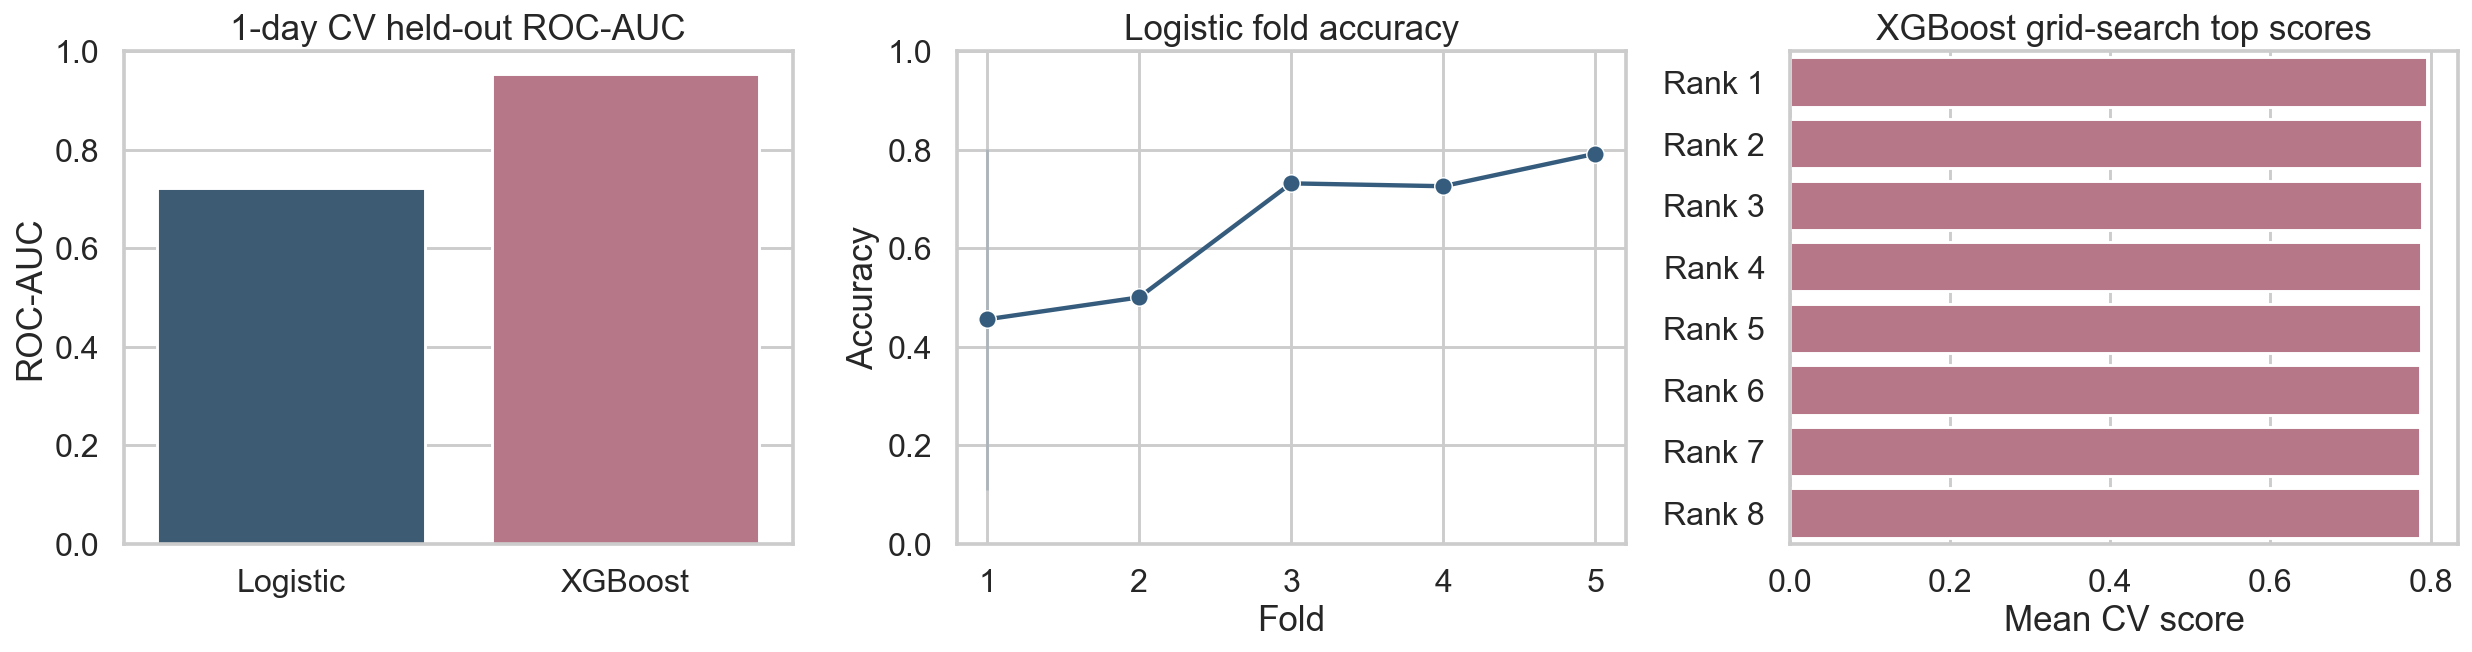

In [32]:
logistic_cv_plot = logistic_cv_folds.copy()
logistic_cv_plot["fold"] = pd.to_numeric(logistic_cv_plot["fold"], errors="coerce")
logistic_cv_plot = logistic_cv_plot.dropna(subset=["fold"]).copy()
logistic_cv_plot["fold"] = logistic_cv_plot["fold"].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=pd.concat([logistic_cv_test, xgb_cv_test], ignore_index=True),
    x="model",
    y="roc_auc",
    hue="model",
    palette=MODEL_COLORS,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("1-day CV held-out ROC-AUC")
axes[0].set_xlabel("")
axes[0].set_ylabel("ROC-AUC")
axes[0].set_ylim(0, 1.0)

sns.lineplot(
    data=logistic_cv_plot,
    x="fold",
    y="accuracy",
    marker="o",
    color=MODEL_COLORS["Logistic"],
    ax=axes[1],
)
axes[1].set_title("Logistic fold accuracy")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.0)

xgb_grid_top = xgb_cv_grid.sort_values("mean_test_score", ascending=False).head(8).copy()
xgb_grid_top["label"] = [f"Rank {rank}" for rank in xgb_grid_top["rank_test_score"]]
sns.barplot(data=xgb_grid_top, x="mean_test_score", y="label", color=MODEL_COLORS["XGBoost"], ax=axes[2])
axes[2].set_title("XGBoost grid-search top scores")
axes[2].set_xlabel("Mean CV score")
axes[2].set_ylabel("")

plt.tight_layout()
save_current_figure("cross_validation_overview.png")
plt.show()


## Confusion Matrix Gallery

The forecasting artifacts are now aligned enough that the confusion matrices can be shown in a single grid.


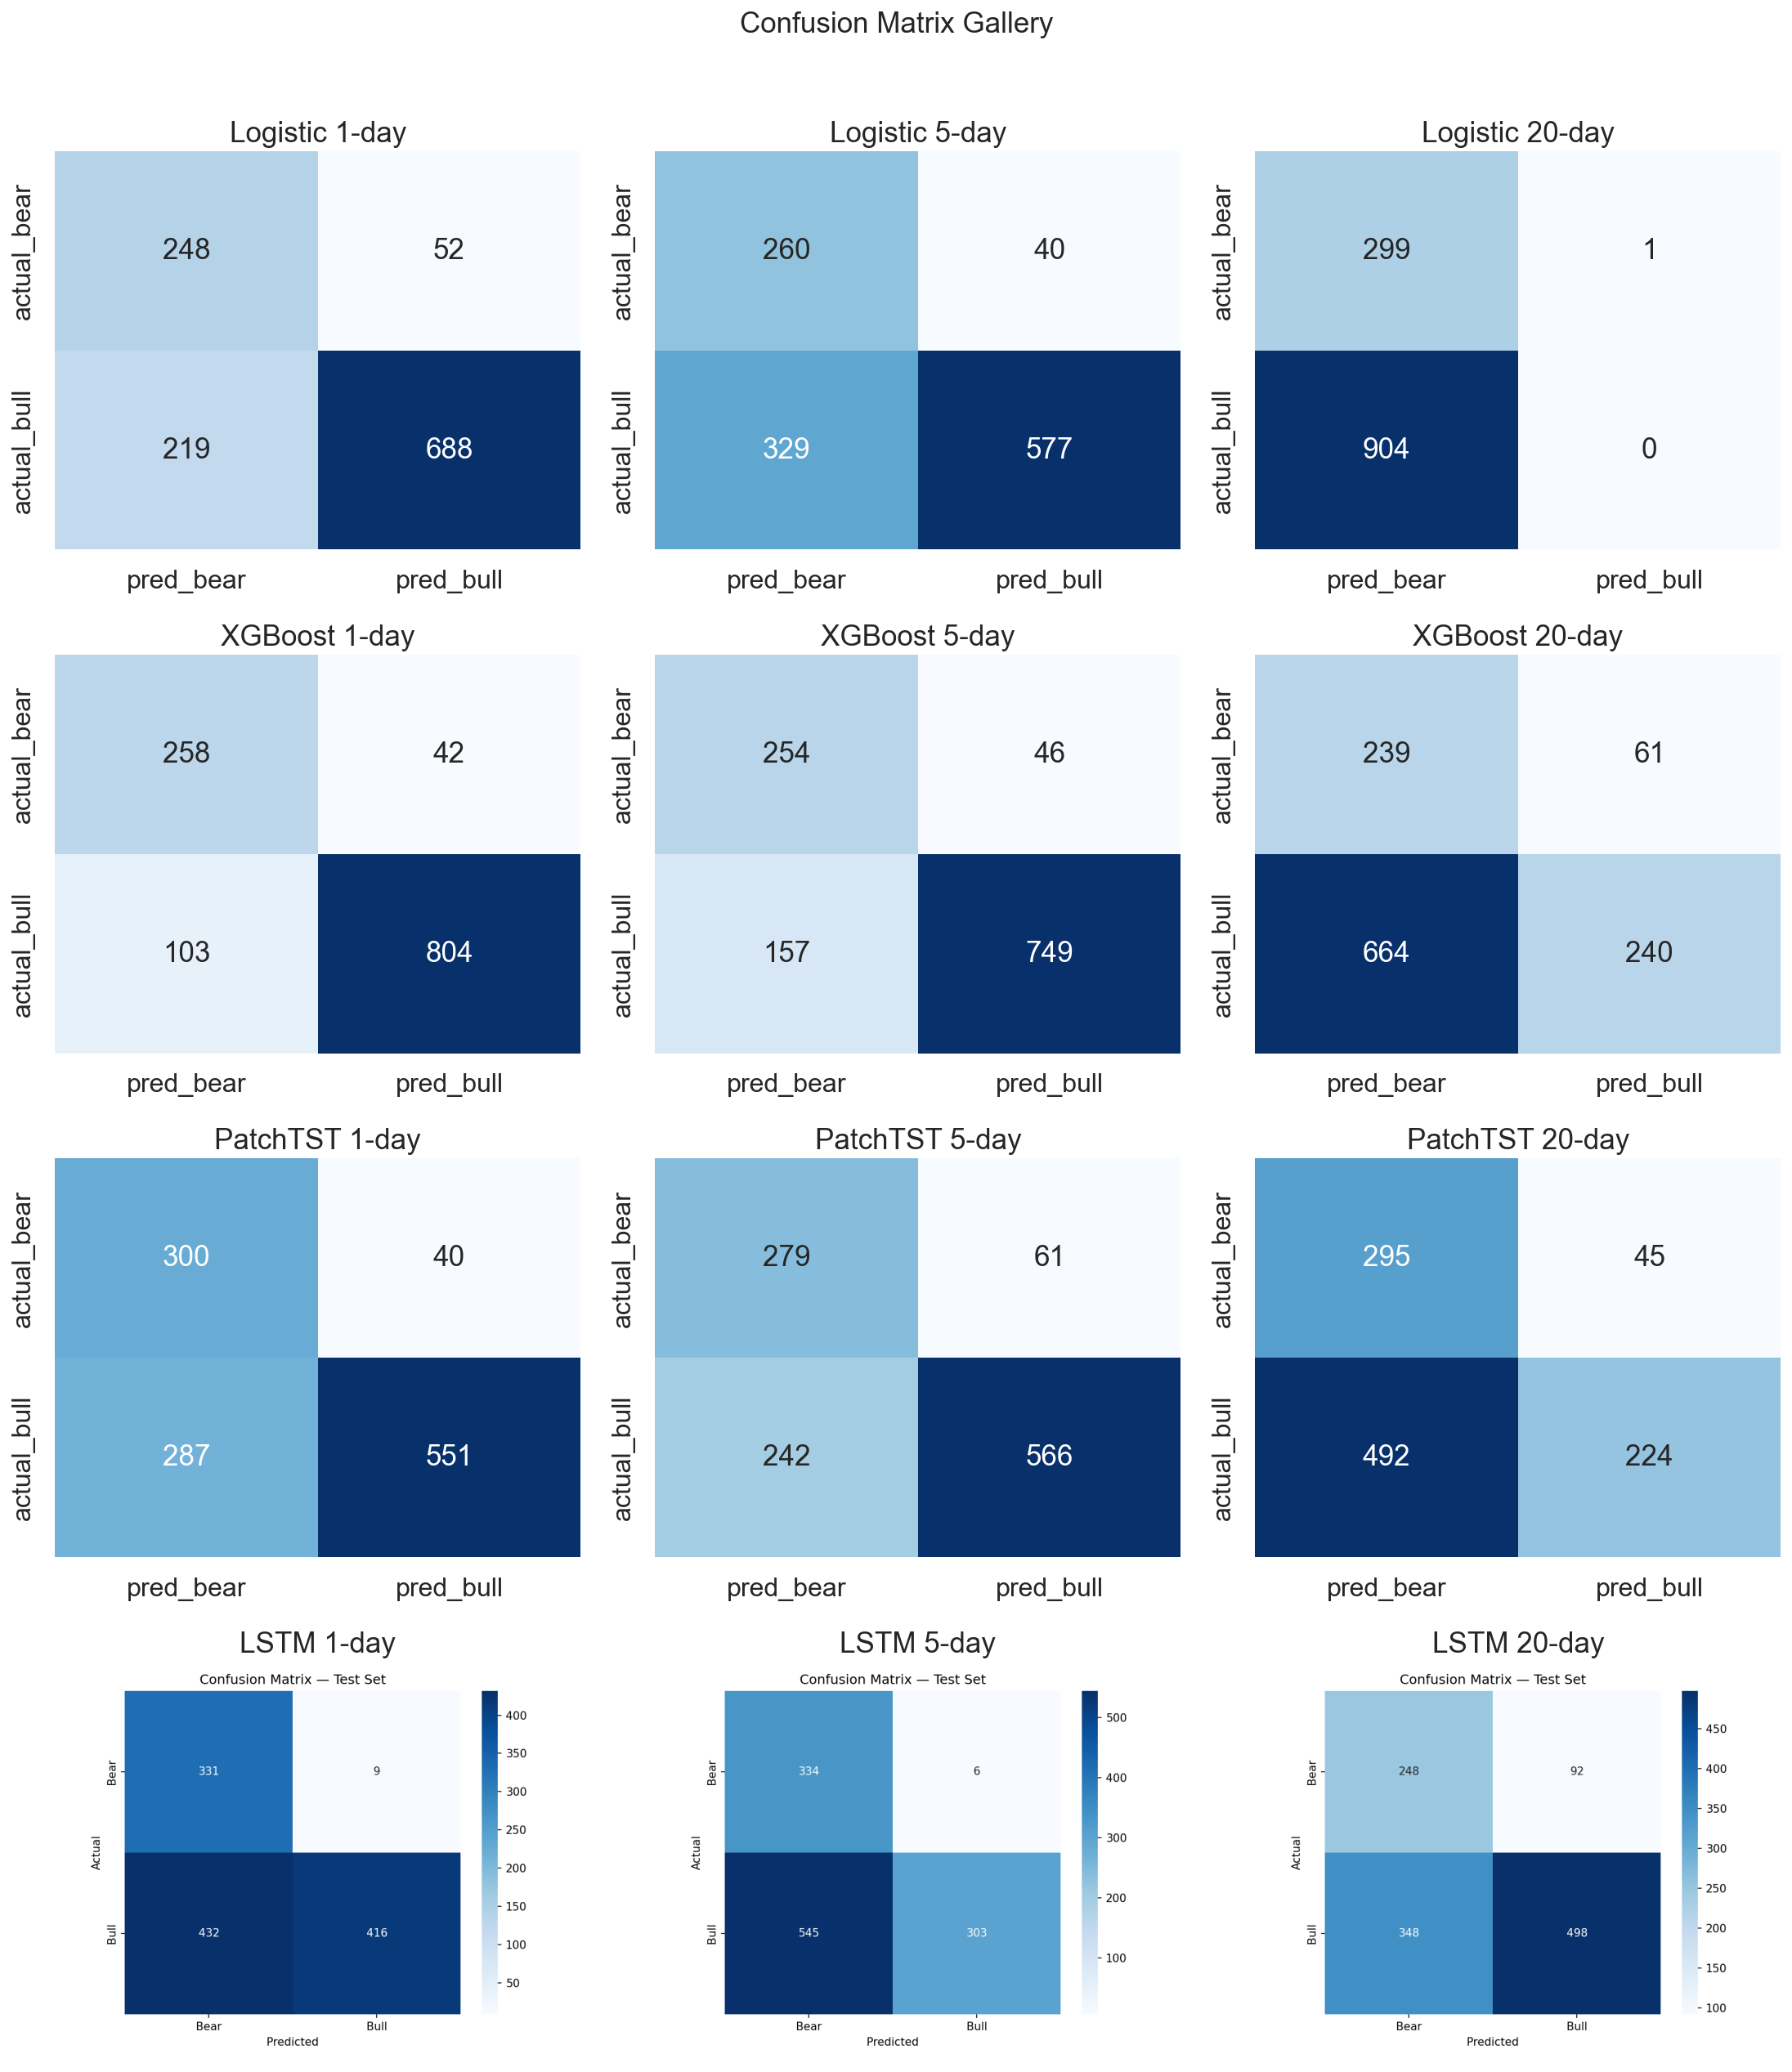

In [33]:
confusion_specs = [
    ("Logistic 1-day", REPORTS_DIR / "trained_logistic" / "basecase_1day" / "confusion_matrix.csv", None),
    ("Logistic 5-day", REPORTS_DIR / "trained_logistic" / "basecase_5days" / "confusion_matrix.csv", None),
    ("Logistic 20-day", REPORTS_DIR / "trained_logistic" / "basecase_20days" / "confusion_matrix.csv", None),
    ("XGBoost 1-day", REPORTS_DIR / "trained_xgboost" / "basecase_1day" / "confusion_matrix.csv", None),
    ("XGBoost 5-day", REPORTS_DIR / "trained_xgboost" / "basecase_5days" / "confusion_matrix.csv", None),
    ("XGBoost 20-day", REPORTS_DIR / "trained_xgboost" / "basecase_20days" / "confusion_matrix.csv", None),
    ("PatchTST 1-day", REPORTS_DIR / "trained_patchtst" / "results_lag_1" / "confusion_matrix.csv", None),
    ("PatchTST 5-day", REPORTS_DIR / "trained_patchtst" / "results_lag_5" / "confusion_matrix.csv", None),
    ("PatchTST 20-day", REPORTS_DIR / "trained_patchtst" / "results_lag_20" / "confusion_matrix.csv", None),
    ("LSTM 1-day", None, REPORTS_DIR / "trained_ltsm" / "results_lag_1" / "confusion_matrix.png"),
    ("LSTM 5-day", None, REPORTS_DIR / "trained_ltsm" / "results_lag_5" / "confusion_matrix.png"),
    ("LSTM 20-day", None, REPORTS_DIR / "trained_ltsm" / "results_lag_20" / "confusion_matrix.png"),
]

fig, axes = plt.subplots(4, 3, figsize=(16, 18))
for ax, (title, csv_path, image_path) in zip(axes.ravel(), confusion_specs):
    draw_confusion_artifact(ax, title, csv_path=csv_path, image_path=image_path)

plt.suptitle("Confusion Matrix Gallery", y=1.01, fontsize=18)
plt.tight_layout()
save_current_figure("confusion_matrix_gallery.png")
plt.show()


## Saved Diagnostic Gallery

These are the original exported single-model diagnostic views, preserved here as a quick report appendix.


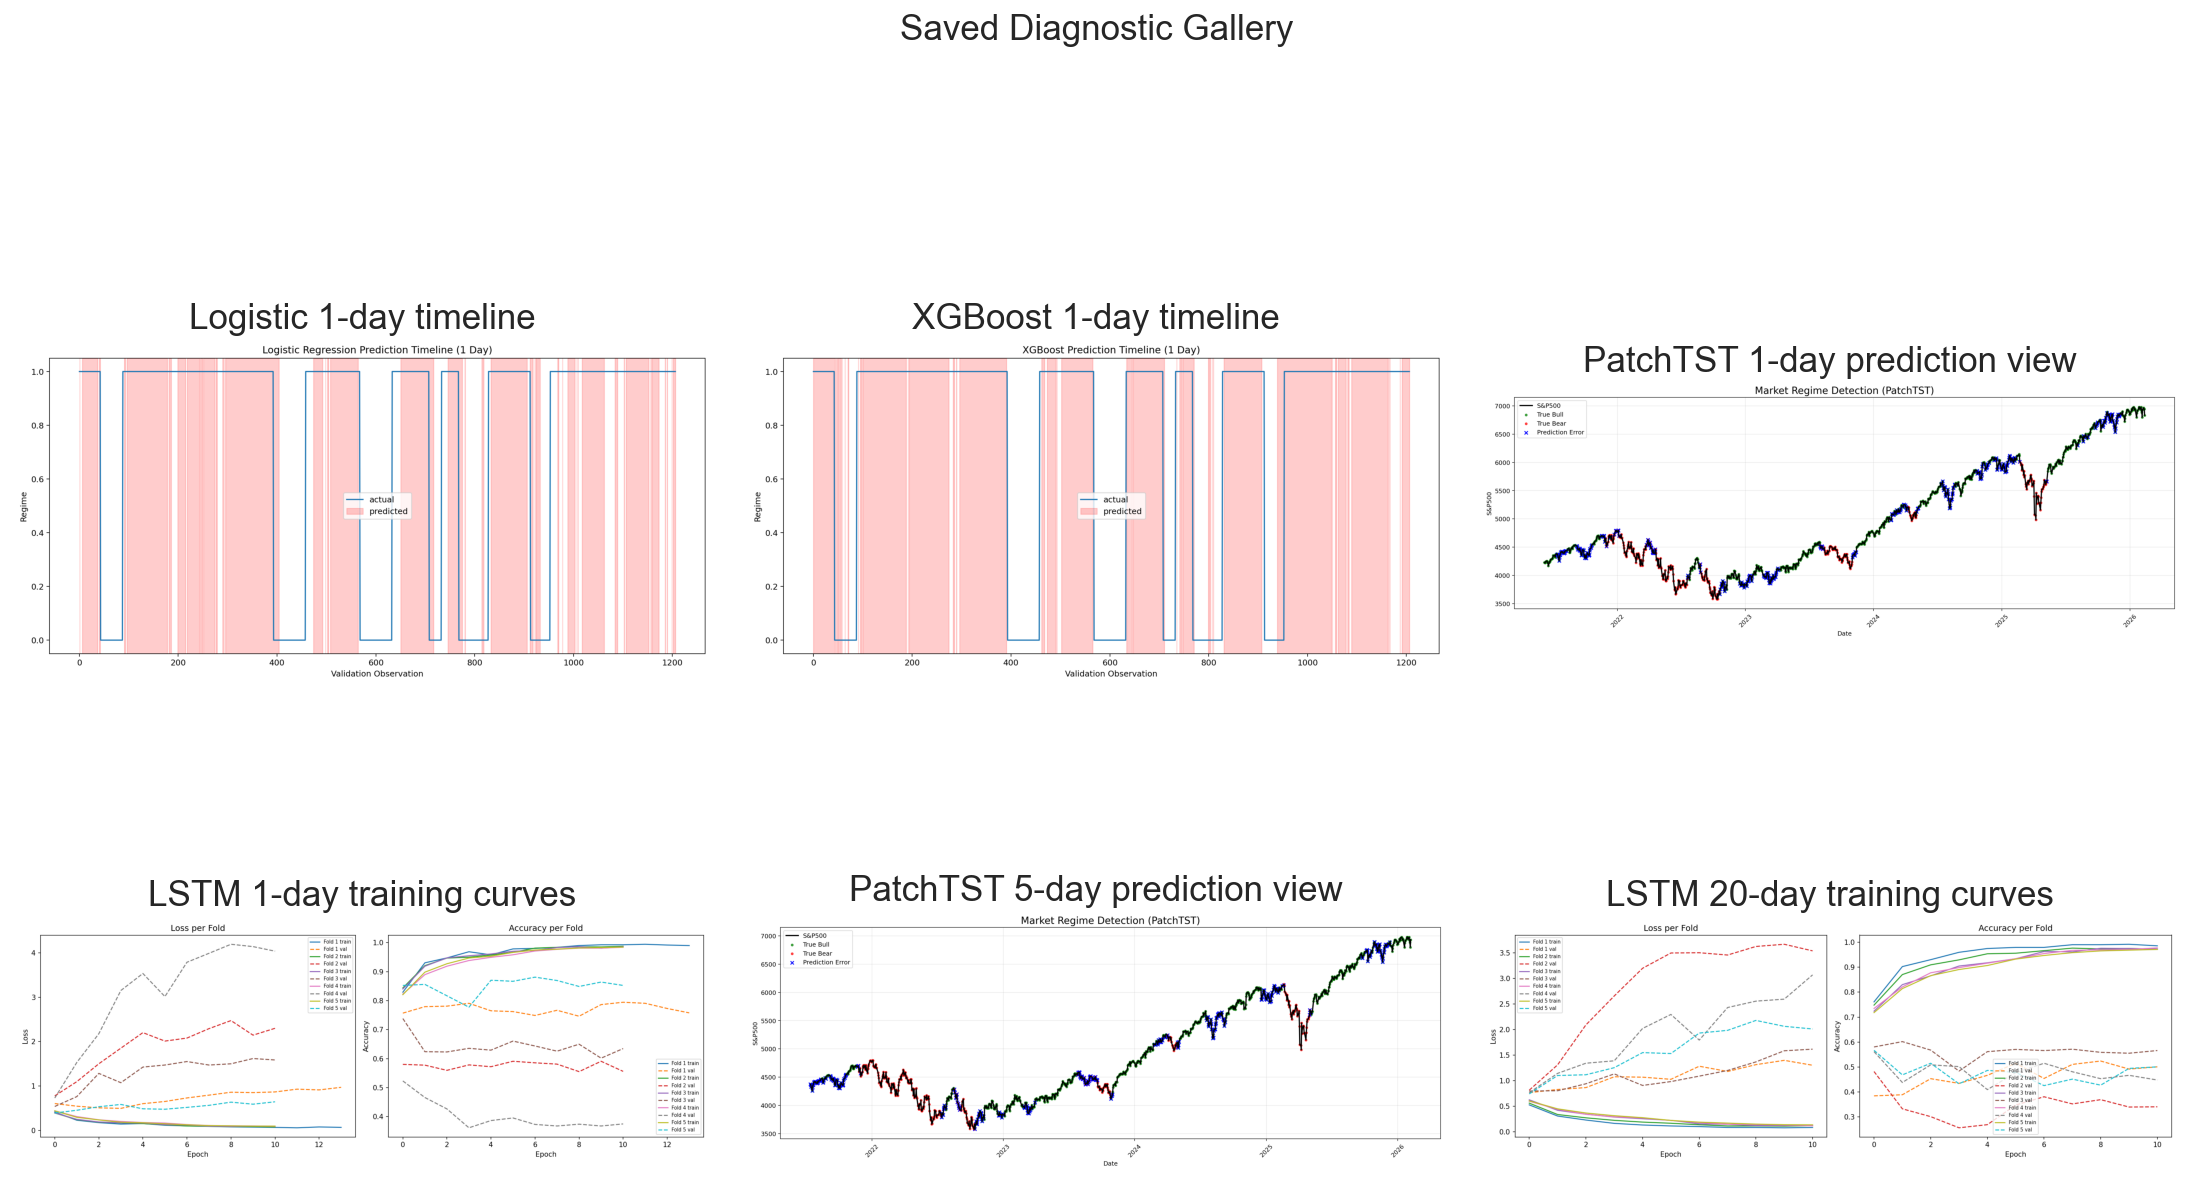

In [34]:
image_specs = [
    ("Logistic 1-day timeline", REPORTS_DIR / "trained_logistic" / "basecase_1day" / "prediction_timeline.png"),
    ("XGBoost 1-day timeline", REPORTS_DIR / "trained_xgboost" / "basecase_1day" / "prediction_timeline.png"),
    ("PatchTST 1-day prediction view", REPORTS_DIR / "trained_patchtst" / "results_lag_1" / "prediction_visualisation.png"),
    ("LSTM 1-day training curves", REPORTS_DIR / "trained_ltsm" / "results_lag_1" / "training_curves.png"),
    ("PatchTST 5-day prediction view", REPORTS_DIR / "trained_patchtst" / "results_lag_5" / "prediction_visualisation.png"),
    ("LSTM 20-day training curves", REPORTS_DIR / "trained_ltsm" / "results_lag_20" / "training_curves.png"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (title, image_path) in zip(axes.ravel(), image_specs):
    if image_path.exists():
        img = mpimg.imread(image_path)
        ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")
    else:
        ax.text(0.5, 0.5, "Missing artifact", ha="center", va="center")
        ax.set_title(title)
        ax.axis("off")

plt.suptitle("Saved Diagnostic Gallery", y=1.02, fontsize=18)
plt.tight_layout()
save_current_figure("saved_diagnostic_gallery.png")
plt.show()
